
=== RUN 1 ===

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.676
Model:                            OLS   Adj. R-squared:                  0.675
Method:                 Least Squares   F-statistic:                     909.3
Date:                Tue, 23 Sep 2025   Prob (F-statistic):          2.85e-319
Time:                        19:45:39   Log-Likelihood:                 4515.1
No. Observations:                1311   AIC:                            -9022.
Df Residuals:                    1307   BIC:                            -9001.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0735      0.008    

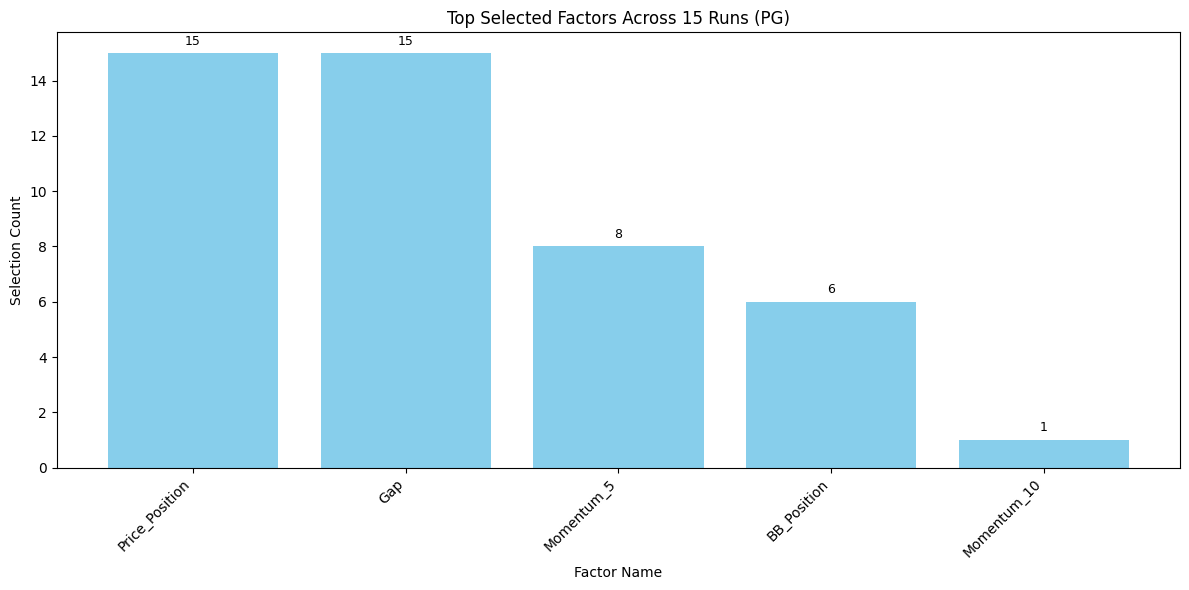

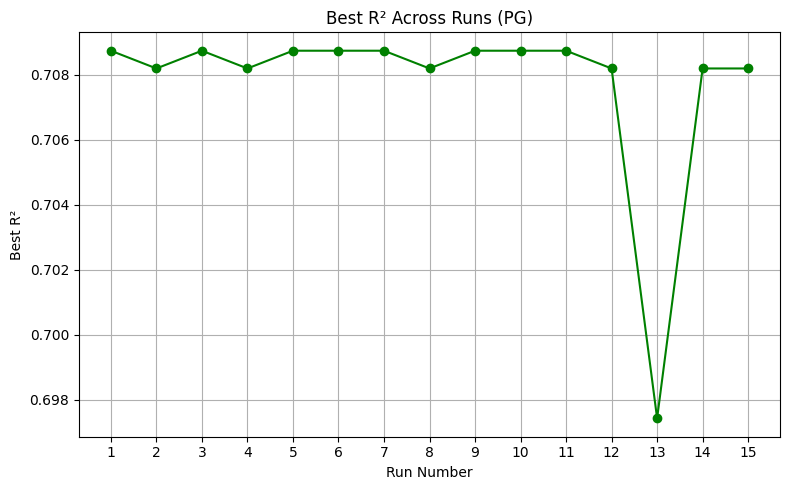

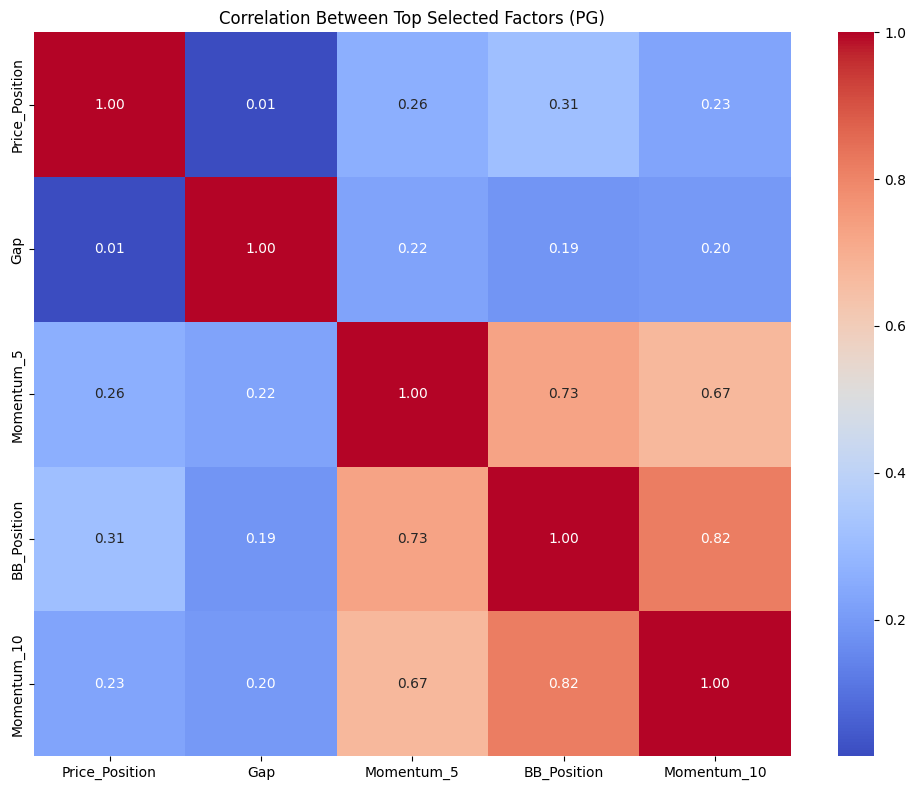

In [ ]:
# ==========================================================
# Code for Genetic Algorithm and Regression
# ==========================================================
import statsmodels.api as sm
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# ==========================================================
# Load data
# ==========================================================
file_path = 'PG_daily_data.csv'
df_data = pd.read_csv(file_path, engine='python', on_bad_lines='skip')
df_data.columns = df_data.columns.str.strip()
df_data = df_data.drop(columns=['Log_Return','Cumulative_Return'], errors='ignore')

# Factor and target columns
factor_start_index = 6
factor_end_index = 65
available_factors = df_data.columns[factor_start_index:factor_end_index + 1].tolist()
target_col = 'Return'


# ==========================================================
# GA PARAMETERS
# ==========================================================
POPULATION_SIZE = 200
GENERATIONS = 30
FACTOR_COUNT = 3
MUTATION_RATE = 0.15
N_RUNS = 15

# ==========================================================
# Helper functions
# ==========================================================
def random_chromosome():
    # Randomly sample unique indices
    return random.sample(range(len(available_factors)), FACTOR_COUNT)

def decode(chromosome):
    # Convert index chromosome to factor names
    return [available_factors[i] for i in chromosome]

def fitness(chromosome, verbose=False):
    # Ensure unique factors and target_col is NOT in factors
    factors = list(dict.fromkeys(decode(chromosome)))
    factors = [f for f in factors if f != target_col]

    columns_needed = factors + [target_col]
    subset = df_data[columns_needed].dropna()

    if len(subset) < 50 or len(factors) != FACTOR_COUNT:
        return -999

    X = subset[factors].values
    y = subset[target_col].values.ravel()

    # Debug shapes


    if X.shape[0] != y.shape[0]:
        print("ERROR: X and y have different number of samples!")
        return -999

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, shuffle=False)

    # Add intercept
    X_train = np.column_stack((np.ones(X_train.shape[0]), X_train))
    X_test = np.column_stack((np.ones(X_test.shape[0]), X_test))

    y_train = np.asarray(y_train).ravel()
    y_test = np.asarray(y_test).ravel()

    # Fit OLS
    model = sm.OLS(y_train, X_train).fit()
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)

    if verbose:
        print(model.summary())
        print("Test R²:", score)
    return score

def crossover(p1, p2):
    point = random.randint(1, FACTOR_COUNT - 1)
    child = p1[:point] + p2[point:]
    # Remove duplicates, preserve order
    child = list(dict.fromkeys(child))
    # Fill up if needed
    while len(child) < FACTOR_COUNT:
        gene = random.choice(range(len(available_factors)))
        if gene not in child:
            child.append(gene)
    return child

def mutate(chrom):
    if random.random() < MUTATION_RATE:
        pos = random.randint(0, FACTOR_COUNT-1)
        new_gene = random.choice(range(len(available_factors)))
        while new_gene in chrom:
            new_gene = random.choice(range(len(available_factors)))
        chrom[pos] = new_gene
    # Remove duplicates, fill up if needed
    chrom = list(dict.fromkeys(chrom))
    while len(chrom) < FACTOR_COUNT:
        gene = random.choice(range(len(available_factors)))
        if gene not in chrom:
            chrom.append(gene)
    return chrom

def ensure_unique_population(pop):
    seen = set()
    unique_pop = []
    for chrom in pop:
        key = tuple(sorted(chrom))
        if key not in seen:
            seen.add(key)
            unique_pop.append(chrom)
    return unique_pop

def hamming_distance(c1, c2):
    return sum(g1 != g2 for g1,g2 in zip(c1,c2))

# ==========================================================
# GA Loop per run
# ==========================================================
def run_ga_once(run_id):
    print(f"\n=== RUN {run_id+1} ===\n")
    population = [random_chromosome() for _ in range(POPULATION_SIZE)]
    population = ensure_unique_population(population)
    while len(population) < POPULATION_SIZE:
        population.append(random_chromosome())
        population = ensure_unique_population(population)

    best_r2_per_gen = []
    diversity_per_gen = []

    for gen in range(GENERATIONS):
        scores = [(chrom, fitness(chrom)) for chrom in population]
        scores = sorted(scores, key=lambda x: x[1], reverse=True)
        best_r2_per_gen.append(scores[0][1])

        # Diversity: avg Hamming distance
        avg_div = np.mean([
            hamming_distance(population[i], population[j])
            for i in range(len(population)) for j in range(i+1, len(population))
        ])
        diversity_per_gen.append(avg_div)

        #print(f"Generation {gen+1} best R²: {scores[0][1]:.4f}")
        #print("Factors:", decode(scores[0][0]))

        # Selection: top half for crossover
        parents = [chrom for chrom, score in scores[:POPULATION_SIZE//2]]

        new_pop = []
        while len(new_pop) < POPULATION_SIZE:
            p1, p2 = random.sample(parents, 2)
            child = crossover(p1, p2)
            child = mutate(child)
            new_pop.append(child)

        population = ensure_unique_population(new_pop)
        while len(population) < POPULATION_SIZE:
            population.append(random_chromosome())
            population = ensure_unique_population(population)

    #print("\nBest chromosome of run:")
    fitness(scores[0][0], verbose=True)
    return scores[0], best_r2_per_gen, diversity_per_gen

# ==========================================================
# Run GA multiple times
# ==========================================================
all_best_factors = []
all_best_r2 = []
all_r2_evolution = []
all_diversity = []

for i in range(N_RUNS):
    (best_chrom, best_r2), r2_curve, div_curve = run_ga_once(i)
    decoded = decode(best_chrom)
    print(f"\n>>> Run {i+1} Final Best: R² = {best_r2:.4f}, Factors = {decoded}\n")
    all_best_factors.extend(decoded)
    all_best_r2.append(best_r2)
    all_r2_evolution.append(r2_curve)
    all_diversity.append(div_curve)

# ==========================================================
# Analyze and Plot Results
# ==========================================================
factor_counts = Counter(all_best_factors)
print("\n=== Top Selected Factors Across Runs ===")
for f, c in factor_counts.most_common():
    print(f"{f}: {c} times")

# Plot 1: Factor frequency
factors, counts = zip(*factor_counts.most_common())
plt.figure(figsize=(12,6))
bars = plt.bar(factors, counts, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Factor Name")
plt.ylabel("Selection Count")
plt.title(f"Top Selected Factors Across {N_RUNS} Runs (PG)")
plt.tight_layout()
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, yval+0.2, int(yval),
             ha='center', va='bottom', fontsize=9)
plt.show()

# Plot 2: Best R² across runs
plt.figure(figsize=(8,5))
plt.plot(range(1, N_RUNS+1), all_best_r2, marker='o', linestyle='-', color='green')
plt.title("Best R² Across Runs (PG)")
plt.xlabel("Run Number")
plt.ylabel("Best R²")
plt.xticks(range(1, N_RUNS+1))
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot 4: Correlation Heatmap of Top Factors
top_factors = list(factor_counts.keys())
corr = df_data[top_factors].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Top Selected Factors (PG)")
plt.tight_layout()
plt.show()



=== RUN 1 ===

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.743
Method:                 Least Squares   F-statistic:                     1264.
Date:                Tue, 23 Sep 2025   Prob (F-statistic):               0.00
Time:                        19:36:40   Log-Likelihood:                 4102.7
No. Observations:                1311   AIC:                            -8197.
Df Residuals:                    1307   BIC:                            -8177.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0201      0.001    

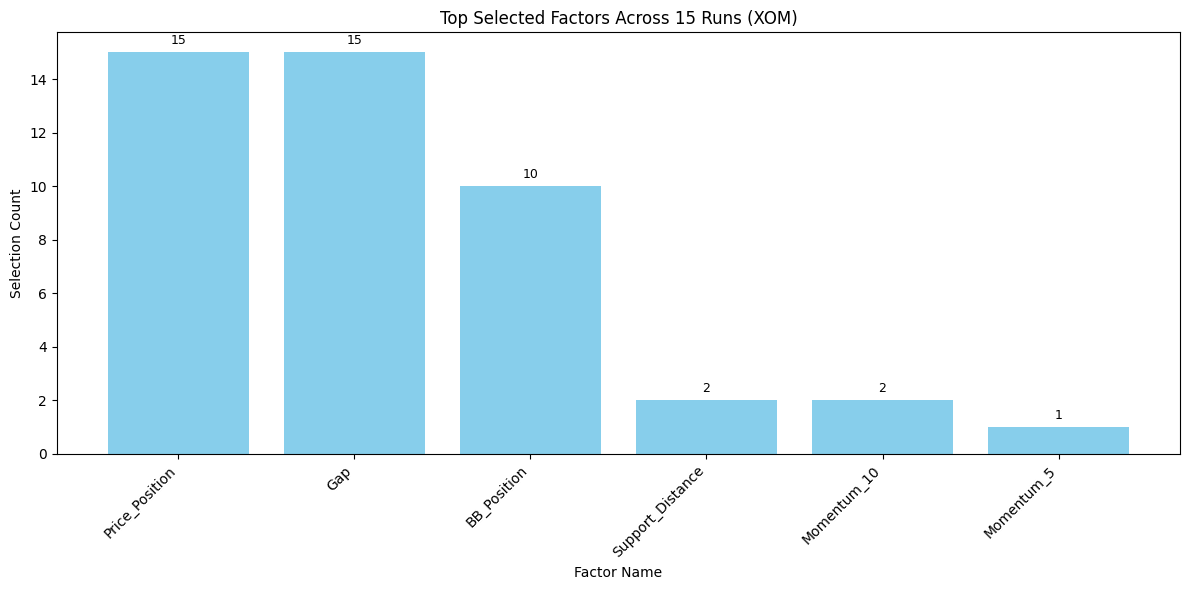

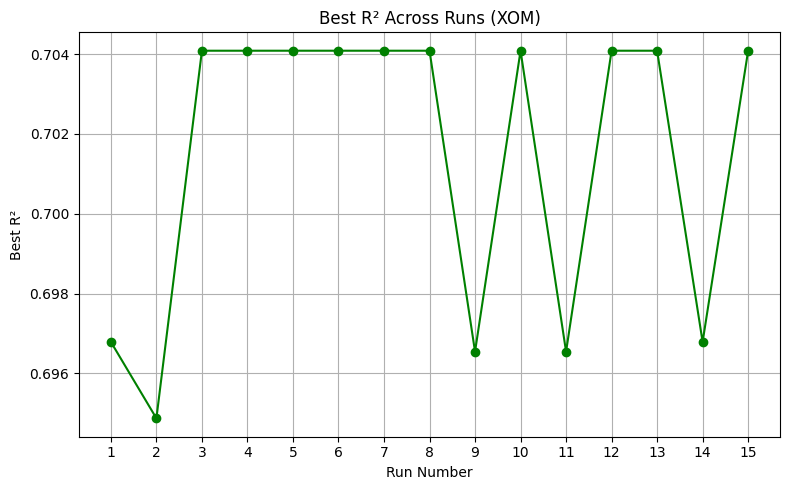

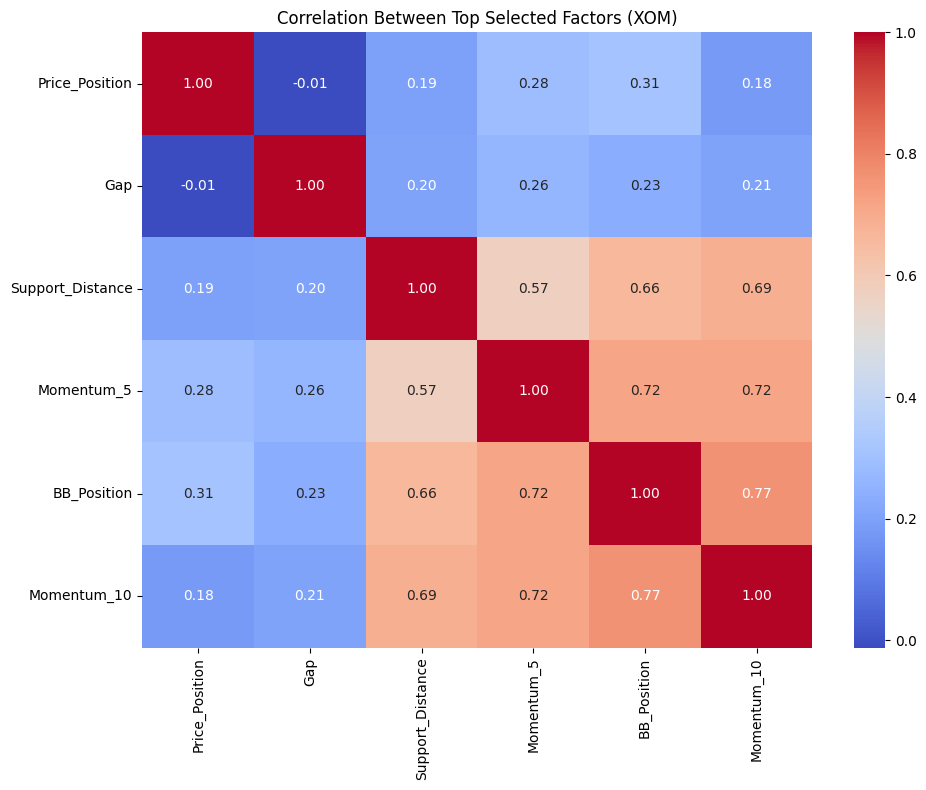

In [ ]:
# ==========================================================
# ==========================================================
import statsmodels.api as sm
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# ==========================================================
# Load data
# ==========================================================
file_path = 'XOM_daily_data.csv'
df_data = pd.read_csv(file_path, engine='python', on_bad_lines='skip')
df_data.columns = df_data.columns.str.strip()
df_data = df_data.drop(columns=['Log_Return','Cumulative_Return'], errors='ignore')

# Factor and target columns
factor_start_index = 6
factor_end_index = 65
available_factors = df_data.columns[factor_start_index:factor_end_index + 1].tolist()
target_col = 'Return'


# ==========================================================
# GA PARAMETERS
# ==========================================================
POPULATION_SIZE = 200
GENERATIONS = 30
FACTOR_COUNT = 3
MUTATION_RATE = 0.15
N_RUNS = 15

# ==========================================================
# Helper functions
# ==========================================================
def random_chromosome():
    # Randomly sample unique indices
    return random.sample(range(len(available_factors)), FACTOR_COUNT)

def decode(chromosome):
    # Convert index chromosome to factor names
    return [available_factors[i] for i in chromosome]

def fitness(chromosome, verbose=False):
    # Ensure unique factors and target_col is NOT in factors
    factors = list(dict.fromkeys(decode(chromosome)))
    factors = [f for f in factors if f != target_col]

    columns_needed = factors + [target_col]
    subset = df_data[columns_needed].dropna()

    if len(subset) < 50 or len(factors) != FACTOR_COUNT:
        return -999

    X = subset[factors].values
    y = subset[target_col].values.ravel()

    # Debug shapes

    if X.shape[0] != y.shape[0]:
        print("ERROR: X and y have different number of samples!")
        return -999

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, shuffle=False)

    # Add intercept
    X_train = np.column_stack((np.ones(X_train.shape[0]), X_train))
    X_test = np.column_stack((np.ones(X_test.shape[0]), X_test))

    y_train = np.asarray(y_train).ravel()
    y_test = np.asarray(y_test).ravel()

    # Fit OLS
    model = sm.OLS(y_train, X_train).fit()
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)

    if verbose:
        print(model.summary())
        print("Test R²:", score)
    return score

def crossover(p1, p2):
    point = random.randint(1, FACTOR_COUNT - 1)
    child = p1[:point] + p2[point:]
    # Remove duplicates, preserve order
    child = list(dict.fromkeys(child))
    # Fill up if needed
    while len(child) < FACTOR_COUNT:
        gene = random.choice(range(len(available_factors)))
        if gene not in child:
            child.append(gene)
    return child

def mutate(chrom):
    if random.random() < MUTATION_RATE:
        pos = random.randint(0, FACTOR_COUNT-1)
        new_gene = random.choice(range(len(available_factors)))
        while new_gene in chrom:
            new_gene = random.choice(range(len(available_factors)))
        chrom[pos] = new_gene
    # Remove duplicates, fill up if needed
    chrom = list(dict.fromkeys(chrom))
    while len(chrom) < FACTOR_COUNT:
        gene = random.choice(range(len(available_factors)))
        if gene not in chrom:
            chrom.append(gene)
    return chrom

def ensure_unique_population(pop):
    seen = set()
    unique_pop = []
    for chrom in pop:
        key = tuple(sorted(chrom))
        if key not in seen:
            seen.add(key)
            unique_pop.append(chrom)
    return unique_pop

def hamming_distance(c1, c2):
    return sum(g1 != g2 for g1,g2 in zip(c1,c2))

# ==========================================================
# GA Loop per run
# ==========================================================
def run_ga_once(run_id):
    print(f"\n=== RUN {run_id+1} ===\n")
    population = [random_chromosome() for _ in range(POPULATION_SIZE)]
    population = ensure_unique_population(population)
    while len(population) < POPULATION_SIZE:
        population.append(random_chromosome())
        population = ensure_unique_population(population)

    best_r2_per_gen = []
    diversity_per_gen = []

    for gen in range(GENERATIONS):
        scores = [(chrom, fitness(chrom)) for chrom in population]
        scores = sorted(scores, key=lambda x: x[1], reverse=True)
        best_r2_per_gen.append(scores[0][1])

        # Diversity: avg Hamming distance
        avg_div = np.mean([
            hamming_distance(population[i], population[j])
            for i in range(len(population)) for j in range(i+1, len(population))
        ])
        diversity_per_gen.append(avg_div)

        #print(f"Generation {gen+1} best R²: {scores[0][1]:.4f}")
        #print("Factors:", decode(scores[0][0]))

        # Selection: top half for crossover
        parents = [chrom for chrom, score in scores[:POPULATION_SIZE//2]]

        new_pop = []
        while len(new_pop) < POPULATION_SIZE:
            p1, p2 = random.sample(parents, 2)
            child = crossover(p1, p2)
            child = mutate(child)
            new_pop.append(child)

        population = ensure_unique_population(new_pop)
        while len(population) < POPULATION_SIZE:
            population.append(random_chromosome())
            population = ensure_unique_population(population)

    #print("\nBest chromosome of run:")
    fitness(scores[0][0], verbose=True)
    return scores[0], best_r2_per_gen, diversity_per_gen

# ==========================================================
# Run GA multiple times
# ==========================================================
all_best_factors = []
all_best_r2 = []
all_r2_evolution = []
all_diversity = []

for i in range(N_RUNS):
    (best_chrom, best_r2), r2_curve, div_curve = run_ga_once(i)
    decoded = decode(best_chrom)
    print(f"\n>>> Run {i+1} Final Best: R² = {best_r2:.4f}, Factors = {decoded}\n")
    all_best_factors.extend(decoded)
    all_best_r2.append(best_r2)
    all_r2_evolution.append(r2_curve)
    all_diversity.append(div_curve)

# ==========================================================
# Analyze and Plot Results
# ==========================================================
factor_counts = Counter(all_best_factors)
print("\n=== Top Selected Factors Across Runs ===")
for f, c in factor_counts.most_common():
    print(f"{f}: {c} times")

# Plot 1: Factor frequency
factors, counts = zip(*factor_counts.most_common())
plt.figure(figsize=(12,6))
bars = plt.bar(factors, counts, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Factor Name")
plt.ylabel("Selection Count")
plt.title(f"Top Selected Factors Across {N_RUNS} Runs (XOM)")
plt.tight_layout()
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, yval+0.2, int(yval),
             ha='center', va='bottom', fontsize=9)
plt.show()

# Plot 2: Best R² across runs
plt.figure(figsize=(8,5))
plt.plot(range(1, N_RUNS+1), all_best_r2, marker='o', linestyle='-', color='green')
plt.title("Best R² Across Runs (XOM)")
plt.xlabel("Run Number")
plt.ylabel("Best R²")
plt.xticks(range(1, N_RUNS+1))
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot 4: Correlation Heatmap of Top Factors
top_factors = list(factor_counts.keys())
corr = df_data[top_factors].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Top Selected Factors (XOM)")
plt.tight_layout()
plt.show()



=== RUN 1 ===

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.786
Model:                            OLS   Adj. R-squared:                  0.785
Method:                 Least Squares   F-statistic:                     1600.
Date:                Wed, 24 Sep 2025   Prob (F-statistic):               0.00
Time:                        07:51:40   Log-Likelihood:                 4228.2
No. Observations:                1311   AIC:                            -8448.
Df Residuals:                    1307   BIC:                            -8428.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0653      0.007    

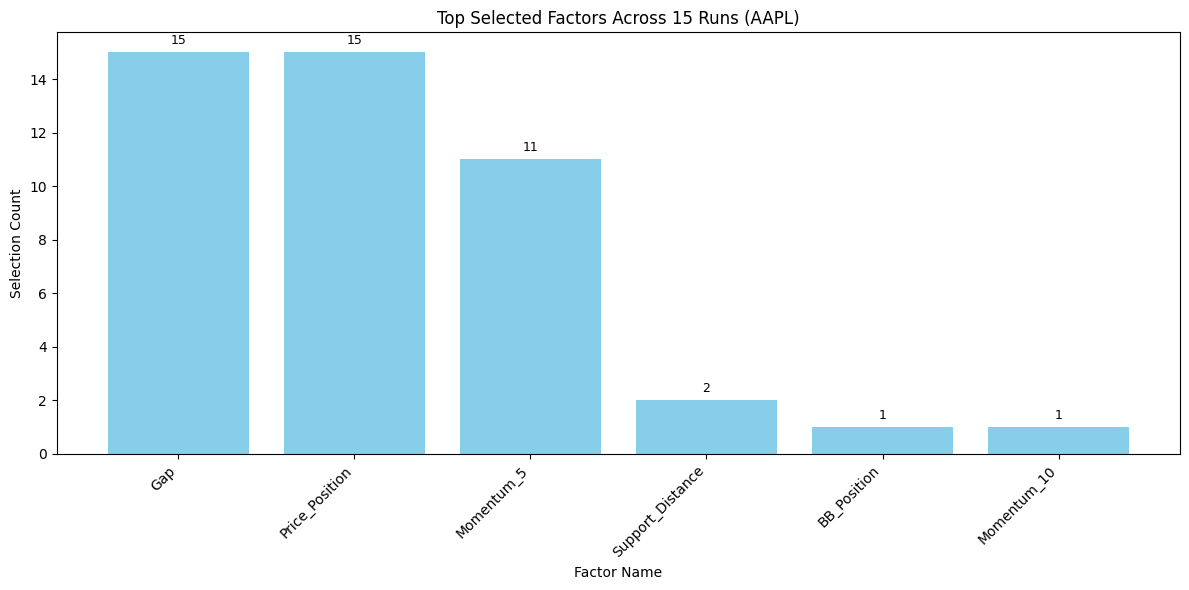

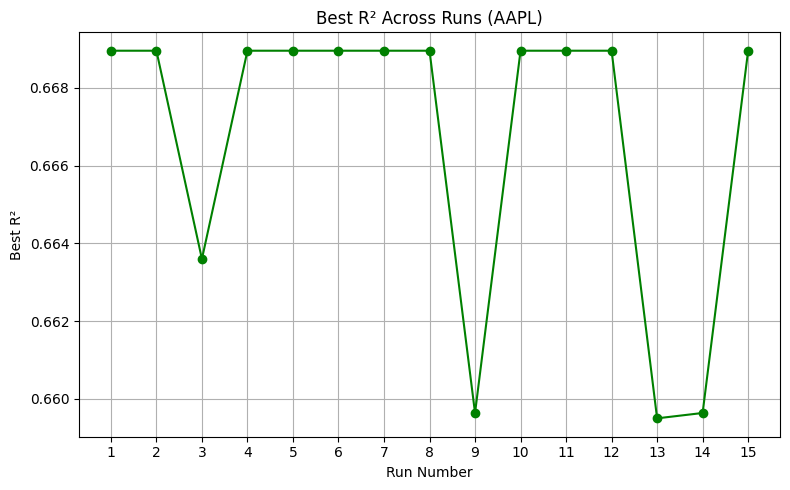

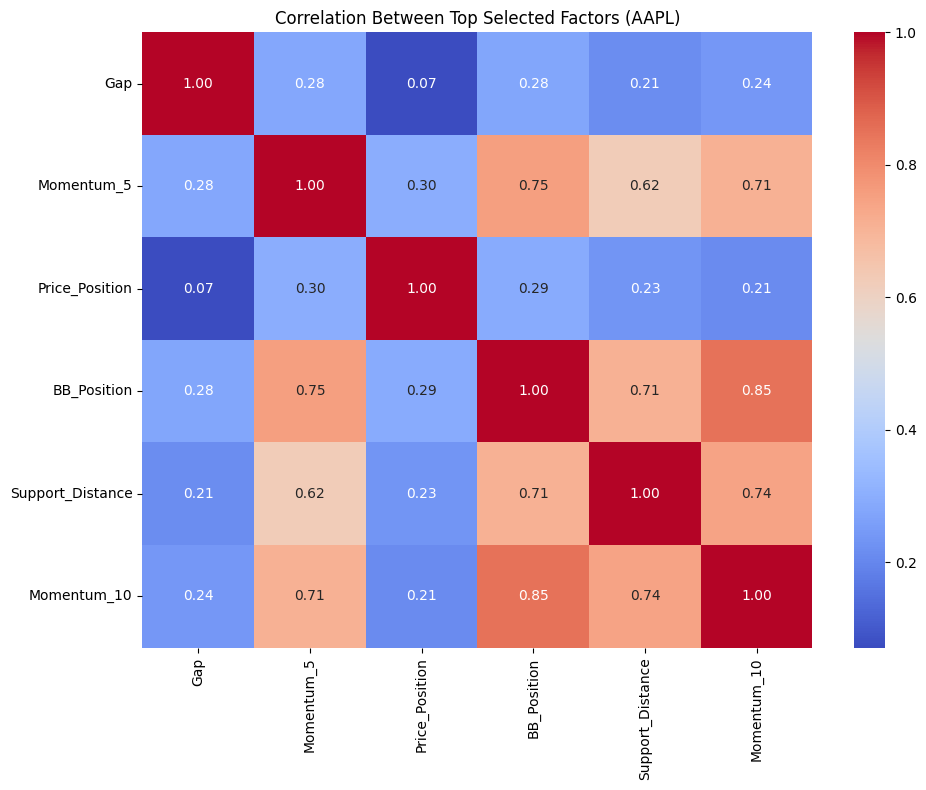

In [ ]:
# ==========================================================
# ==========================================================
import statsmodels.api as sm
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# ==========================================================
# Load data
# ==========================================================
file_path = 'AAPL_daily_data.csv'
df_data = pd.read_csv(file_path, engine='python', on_bad_lines='skip')
df_data.columns = df_data.columns.str.strip()
df_data = df_data.drop(columns=['Log_Return','Cumulative_Return'], errors='ignore')

# Factor and target columns
factor_start_index = 6
factor_end_index = 65
available_factors = df_data.columns[factor_start_index:factor_end_index + 1].tolist()
target_col = 'Return'


# ==========================================================
# GA PARAMETERS
# ==========================================================
POPULATION_SIZE = 200
GENERATIONS = 30
FACTOR_COUNT = 3
MUTATION_RATE = 0.15
N_RUNS = 15

# ==========================================================
# Helper functions
# ==========================================================
def random_chromosome():
    # Randomly sample unique indices
    return random.sample(range(len(available_factors)), FACTOR_COUNT)

def decode(chromosome):
    # Convert index chromosome to factor names
    return [available_factors[i] for i in chromosome]

def fitness(chromosome, verbose=False):
    # Ensure unique factors and target_col is NOT in factors
    factors = list(dict.fromkeys(decode(chromosome)))
    factors = [f for f in factors if f != target_col]

    columns_needed = factors + [target_col]
    subset = df_data[columns_needed].dropna()

    if len(subset) < 50 or len(factors) != FACTOR_COUNT:
        return -999

    X = subset[factors].values
    y = subset[target_col].values.ravel()

    # Debug shapes


    if X.shape[0] != y.shape[0]:
        print("ERROR: X and y have different number of samples!")
        return -999

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, shuffle=False)

    # Add intercept
    X_train = np.column_stack((np.ones(X_train.shape[0]), X_train))
    X_test = np.column_stack((np.ones(X_test.shape[0]), X_test))

    y_train = np.asarray(y_train).ravel()
    y_test = np.asarray(y_test).ravel()

    # Fit OLS
    model = sm.OLS(y_train, X_train).fit()
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)

    if verbose:
        print(model.summary())
        print("Test R²:", score)
    return score

def crossover(p1, p2):
    point = random.randint(1, FACTOR_COUNT - 1)
    child = p1[:point] + p2[point:]
    # Remove duplicates, preserve order
    child = list(dict.fromkeys(child))
    # Fill up if needed
    while len(child) < FACTOR_COUNT:
        gene = random.choice(range(len(available_factors)))
        if gene not in child:
            child.append(gene)
    return child

def mutate(chrom):
    if random.random() < MUTATION_RATE:
        pos = random.randint(0, FACTOR_COUNT-1)
        new_gene = random.choice(range(len(available_factors)))
        while new_gene in chrom:
            new_gene = random.choice(range(len(available_factors)))
        chrom[pos] = new_gene
    # Remove duplicates, fill up if needed
    chrom = list(dict.fromkeys(chrom))
    while len(chrom) < FACTOR_COUNT:
        gene = random.choice(range(len(available_factors)))
        if gene not in chrom:
            chrom.append(gene)
    return chrom

def ensure_unique_population(pop):
    seen = set()
    unique_pop = []
    for chrom in pop:
        key = tuple(sorted(chrom))
        if key not in seen:
            seen.add(key)
            unique_pop.append(chrom)
    return unique_pop

def hamming_distance(c1, c2):
    return sum(g1 != g2 for g1,g2 in zip(c1,c2))

# ==========================================================
# GA Loop per run
# ==========================================================
def run_ga_once(run_id):
    print(f"\n=== RUN {run_id+1} ===\n")
    population = [random_chromosome() for _ in range(POPULATION_SIZE)]
    population = ensure_unique_population(population)
    while len(population) < POPULATION_SIZE:
        population.append(random_chromosome())
        population = ensure_unique_population(population)

    best_r2_per_gen = []
    diversity_per_gen = []

    for gen in range(GENERATIONS):
        scores = [(chrom, fitness(chrom)) for chrom in population]
        scores = sorted(scores, key=lambda x: x[1], reverse=True)
        best_r2_per_gen.append(scores[0][1])

        # Diversity: avg Hamming distance
        avg_div = np.mean([
            hamming_distance(population[i], population[j])
            for i in range(len(population)) for j in range(i+1, len(population))
        ])
        diversity_per_gen.append(avg_div)

        #print(f"Generation {gen+1} best R²: {scores[0][1]:.4f}")
        #print("Factors:", decode(scores[0][0]))

        # Selection: top half for crossover
        parents = [chrom for chrom, score in scores[:POPULATION_SIZE//2]]

        new_pop = []
        while len(new_pop) < POPULATION_SIZE:
            p1, p2 = random.sample(parents, 2)
            child = crossover(p1, p2)
            child = mutate(child)
            new_pop.append(child)

        population = ensure_unique_population(new_pop)
        while len(population) < POPULATION_SIZE:
            population.append(random_chromosome())
            population = ensure_unique_population(population)

    #print("\nBest chromosome of run:")
    fitness(scores[0][0], verbose=True)
    return scores[0], best_r2_per_gen, diversity_per_gen

# ==========================================================
# Run GA multiple times
# ==========================================================
all_best_factors = []
all_best_r2 = []
all_r2_evolution = []
all_diversity = []

for i in range(N_RUNS):
    (best_chrom, best_r2), r2_curve, div_curve = run_ga_once(i)
    decoded = decode(best_chrom)
    print(f"\n>>> Run {i+1} Final Best: R² = {best_r2:.4f}, Factors = {decoded}\n")
    all_best_factors.extend(decoded)
    all_best_r2.append(best_r2)
    all_r2_evolution.append(r2_curve)
    all_diversity.append(div_curve)

# ==========================================================
# Analyze and Plot Results
# ==========================================================
factor_counts = Counter(all_best_factors)
print("\n=== Top Selected Factors Across Runs ===")
for f, c in factor_counts.most_common():
    print(f"{f}: {c} times")

# Plot 1: Factor frequency
factors, counts = zip(*factor_counts.most_common())
plt.figure(figsize=(12,6))
bars = plt.bar(factors, counts, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Factor Name")
plt.ylabel("Selection Count")
plt.title(f"Top Selected Factors Across {N_RUNS} Runs (AAPL)")
plt.tight_layout()
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, yval+0.2, int(yval),
             ha='center', va='bottom', fontsize=9)
plt.show()

# Plot 2: Best R² across runs
plt.figure(figsize=(8,5))
plt.plot(range(1, N_RUNS+1), all_best_r2, marker='o', linestyle='-', color='green')
plt.title("Best R² Across Runs (AAPL)")
plt.xlabel("Run Number")
plt.ylabel("Best R²")
plt.xticks(range(1, N_RUNS+1))
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot 4: Correlation Heatmap of Top Factors
top_factors = list(factor_counts.keys())
corr = df_data[top_factors].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Top Selected Factors (AAPL)")
plt.tight_layout()
plt.show()



=== RUN 1 ===

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.779
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     1534.
Date:                Wed, 24 Sep 2025   Prob (F-statistic):               0.00
Time:                        07:58:28   Log-Likelihood:                 4264.7
No. Observations:                1311   AIC:                            -8521.
Df Residuals:                    1307   BIC:                            -8501.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0262      0.005    

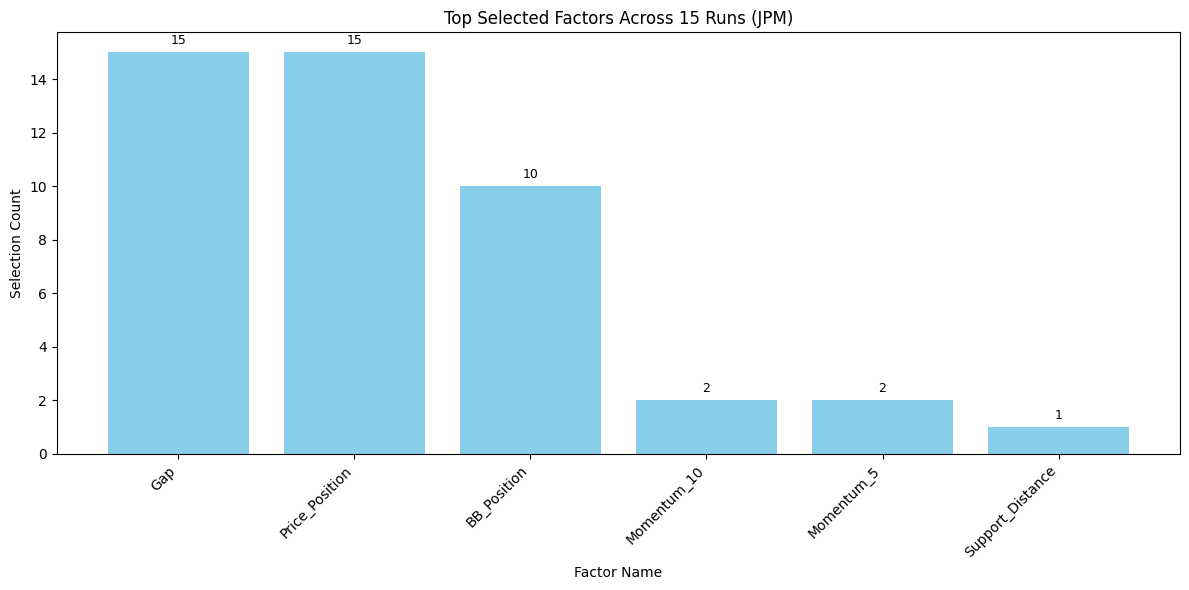

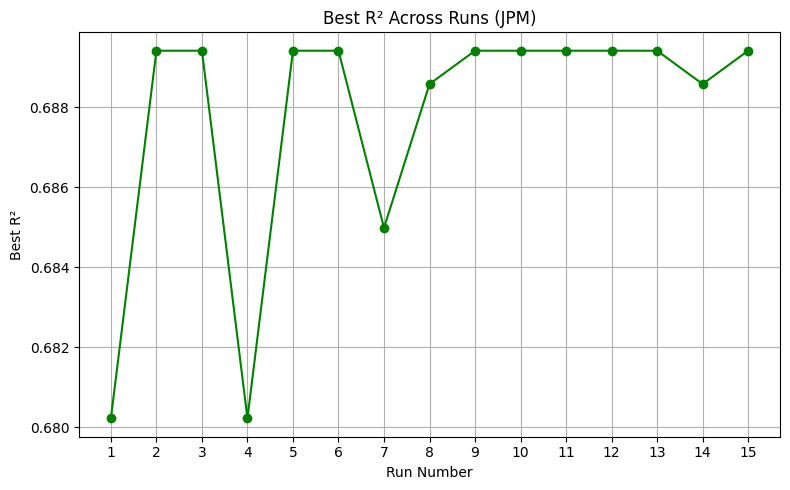

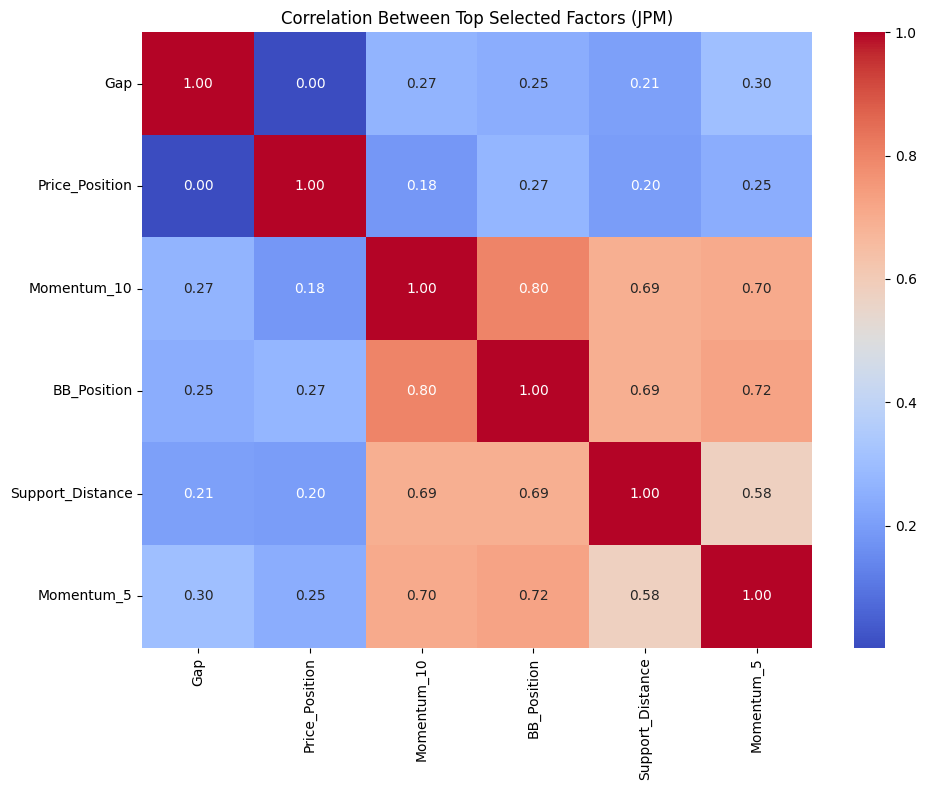

In [ ]:
# ==========================================================
# ==========================================================
import statsmodels.api as sm
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# ==========================================================
# Load data
# ==========================================================
file_path = 'JPM_daily_data.csv'
df_data = pd.read_csv(file_path, engine='python', on_bad_lines='skip')
df_data.columns = df_data.columns.str.strip()
df_data = df_data.drop(columns=['Log_Return','Cumulative_Return'], errors='ignore')

# Factor and target columns
factor_start_index = 6
factor_end_index = 65
available_factors = df_data.columns[factor_start_index:factor_end_index + 1].tolist()
target_col = 'Return'


# ==========================================================
# GA PARAMETERS
# ==========================================================
POPULATION_SIZE = 200
GENERATIONS = 30
FACTOR_COUNT = 3
MUTATION_RATE = 0.15
N_RUNS = 15

# ==========================================================
# Helper functions
# ==========================================================
def random_chromosome():
    # Randomly sample unique indices
    return random.sample(range(len(available_factors)), FACTOR_COUNT)

def decode(chromosome):
    # Convert index chromosome to factor names
    return [available_factors[i] for i in chromosome]

def fitness(chromosome, verbose=False):
    # Ensure unique factors and target_col is NOT in factors
    factors = list(dict.fromkeys(decode(chromosome)))
    factors = [f for f in factors if f != target_col]

    columns_needed = factors + [target_col]
    subset = df_data[columns_needed].dropna()

    if len(subset) < 50 or len(factors) != FACTOR_COUNT:
        return -999

    X = subset[factors].values
    y = subset[target_col].values.ravel()

    # Debug shapes


    if X.shape[0] != y.shape[0]:
        print("ERROR: X and y have different number of samples!")
        return -999

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, shuffle=False)

    # Add intercept
    X_train = np.column_stack((np.ones(X_train.shape[0]), X_train))
    X_test = np.column_stack((np.ones(X_test.shape[0]), X_test))

    y_train = np.asarray(y_train).ravel()
    y_test = np.asarray(y_test).ravel()

    # Fit OLS
    model = sm.OLS(y_train, X_train).fit()
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)

    if verbose:
        print(model.summary())
        print("Test R²:", score)
    return score

def crossover(p1, p2):
    point = random.randint(1, FACTOR_COUNT - 1)
    child = p1[:point] + p2[point:]
    # Remove duplicates, preserve order
    child = list(dict.fromkeys(child))
    # Fill up if needed
    while len(child) < FACTOR_COUNT:
        gene = random.choice(range(len(available_factors)))
        if gene not in child:
            child.append(gene)
    return child

def mutate(chrom):
    if random.random() < MUTATION_RATE:
        pos = random.randint(0, FACTOR_COUNT-1)
        new_gene = random.choice(range(len(available_factors)))
        while new_gene in chrom:
            new_gene = random.choice(range(len(available_factors)))
        chrom[pos] = new_gene
    # Remove duplicates, fill up if needed
    chrom = list(dict.fromkeys(chrom))
    while len(chrom) < FACTOR_COUNT:
        gene = random.choice(range(len(available_factors)))
        if gene not in chrom:
            chrom.append(gene)
    return chrom

def ensure_unique_population(pop):
    seen = set()
    unique_pop = []
    for chrom in pop:
        key = tuple(sorted(chrom))
        if key not in seen:
            seen.add(key)
            unique_pop.append(chrom)
    return unique_pop

def hamming_distance(c1, c2):
    return sum(g1 != g2 for g1,g2 in zip(c1,c2))

# ==========================================================
# GA Loop per run
# ==========================================================
def run_ga_once(run_id):
    print(f"\n=== RUN {run_id+1} ===\n")
    population = [random_chromosome() for _ in range(POPULATION_SIZE)]
    population = ensure_unique_population(population)
    while len(population) < POPULATION_SIZE:
        population.append(random_chromosome())
        population = ensure_unique_population(population)

    best_r2_per_gen = []
    diversity_per_gen = []

    for gen in range(GENERATIONS):
        scores = [(chrom, fitness(chrom)) for chrom in population]
        scores = sorted(scores, key=lambda x: x[1], reverse=True)
        best_r2_per_gen.append(scores[0][1])

        # Diversity: avg Hamming distance
        avg_div = np.mean([
            hamming_distance(population[i], population[j])
            for i in range(len(population)) for j in range(i+1, len(population))
        ])
        diversity_per_gen.append(avg_div)

        #print(f"Generation {gen+1} best R²: {scores[0][1]:.4f}")
        #print("Factors:", decode(scores[0][0]))

        # Selection: top half for crossover
        parents = [chrom for chrom, score in scores[:POPULATION_SIZE//2]]

        new_pop = []
        while len(new_pop) < POPULATION_SIZE:
            p1, p2 = random.sample(parents, 2)
            child = crossover(p1, p2)
            child = mutate(child)
            new_pop.append(child)

        population = ensure_unique_population(new_pop)
        while len(population) < POPULATION_SIZE:
            population.append(random_chromosome())
            population = ensure_unique_population(population)

    #print("\nBest chromosome of run:")
    fitness(scores[0][0], verbose=True)
    return scores[0], best_r2_per_gen, diversity_per_gen

# ==========================================================
# Run GA multiple times
# ==========================================================
all_best_factors = []
all_best_r2 = []
all_r2_evolution = []
all_diversity = []

for i in range(N_RUNS):
    (best_chrom, best_r2), r2_curve, div_curve = run_ga_once(i)
    decoded = decode(best_chrom)
    print(f"\n>>> Run {i+1} Final Best: R² = {best_r2:.4f}, Factors = {decoded}\n")
    all_best_factors.extend(decoded)
    all_best_r2.append(best_r2)
    all_r2_evolution.append(r2_curve)
    all_diversity.append(div_curve)

# ==========================================================
# Analyze and Plot Results
# ==========================================================
factor_counts = Counter(all_best_factors)
print("\n=== Top Selected Factors Across Runs ===")
for f, c in factor_counts.most_common():
    print(f"{f}: {c} times")

# Plot 1: Factor frequency
factors, counts = zip(*factor_counts.most_common())
plt.figure(figsize=(12,6))
bars = plt.bar(factors, counts, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Factor Name")
plt.ylabel("Selection Count")
plt.title(f"Top Selected Factors Across {N_RUNS} Runs (JPM)")
plt.tight_layout()
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, yval+0.2, int(yval),
             ha='center', va='bottom', fontsize=9)
plt.show()

# Plot 2: Best R² across runs
plt.figure(figsize=(8,5))
plt.plot(range(1, N_RUNS+1), all_best_r2, marker='o', linestyle='-', color='green')
plt.title("Best R² Across Runs (JPM)")
plt.xlabel("Run Number")
plt.ylabel("Best R²")
plt.xticks(range(1, N_RUNS+1))
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot 4: Correlation Heatmap of Top Factors
top_factors = list(factor_counts.keys())
corr = df_data[top_factors].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Top Selected Factors (JPM)")
plt.tight_layout()
plt.show()



=== RUN 1 ===

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.669
Method:                 Least Squares   F-statistic:                     885.1
Date:                Wed, 24 Sep 2025   Prob (F-statistic):          3.95e-314
Time:                        08:27:11   Log-Likelihood:                 4564.1
No. Observations:                1311   AIC:                            -9120.
Df Residuals:                    1307   BIC:                            -9100.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0151      0.000    

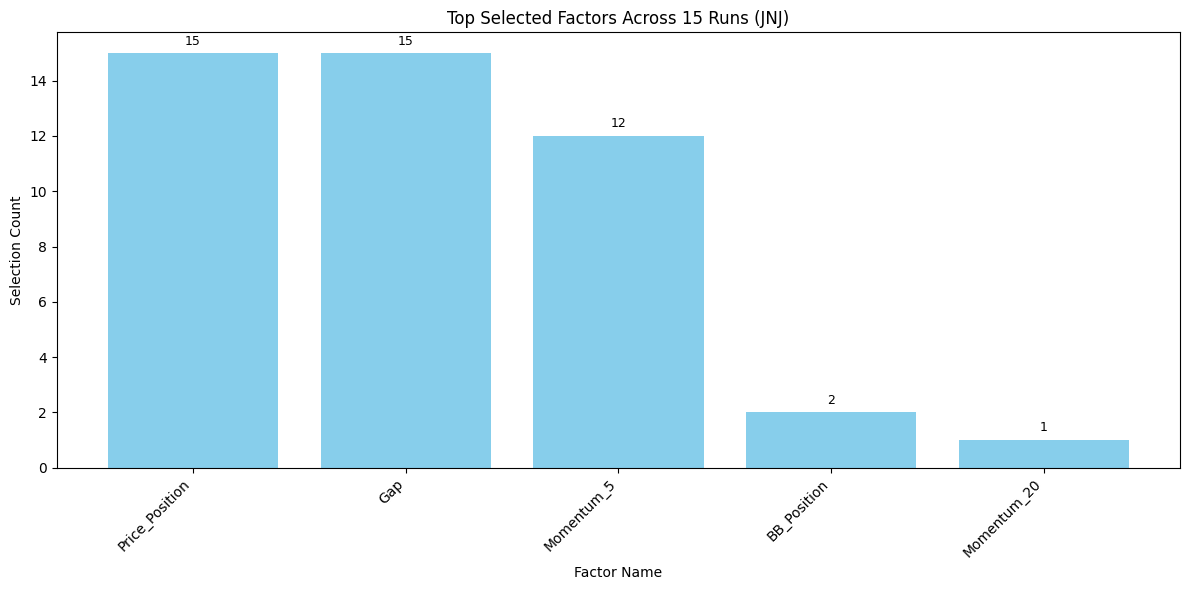

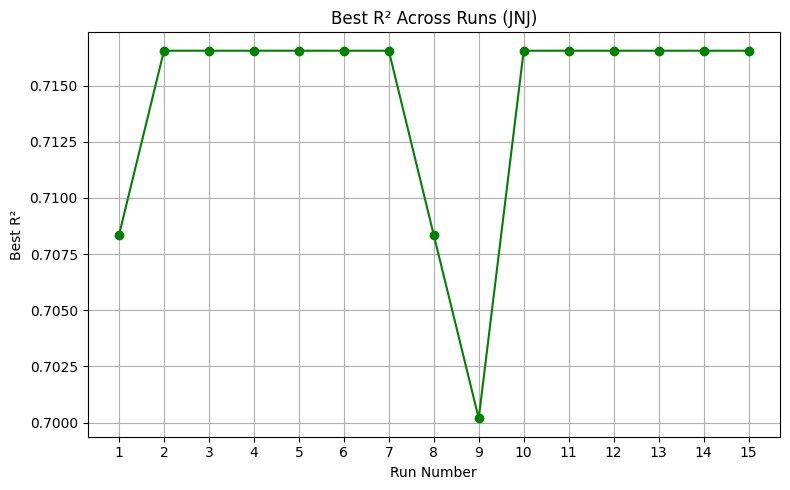

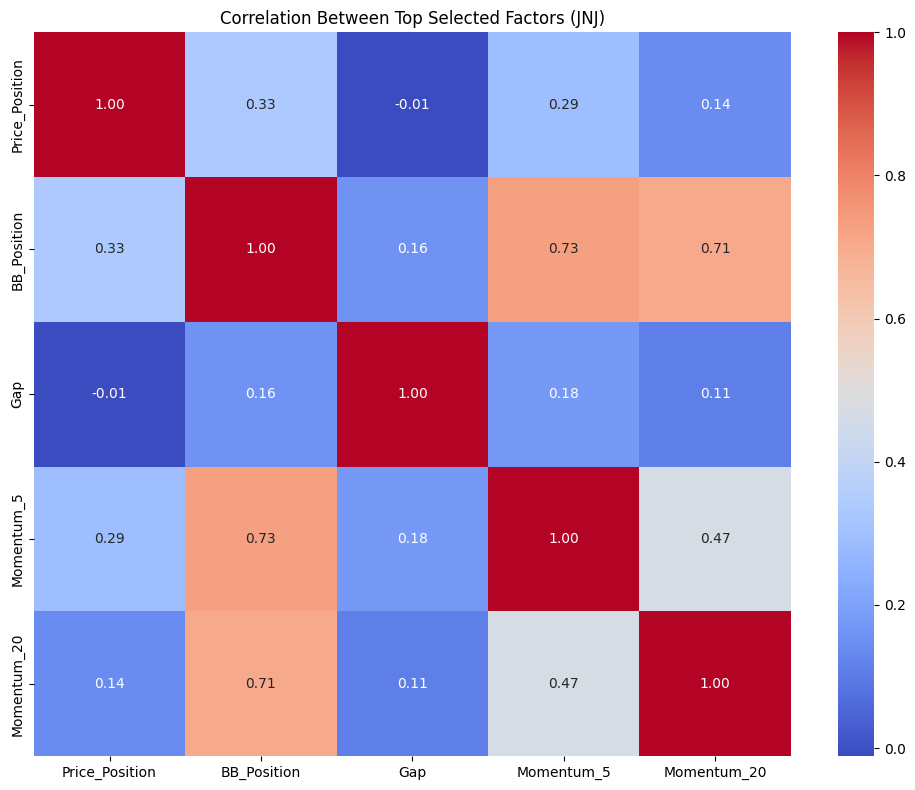

In [ ]:
# ==========================================================
# ==========================================================
import statsmodels.api as sm
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# ==========================================================
# Load data
# ==========================================================
file_path = 'JNJ_daily_data.csv'
df_data = pd.read_csv(file_path, engine='python', on_bad_lines='skip')
df_data.columns = df_data.columns.str.strip()
df_data = df_data.drop(columns=['Log_Return','Cumulative_Return'], errors='ignore')

# Factor and target columns
factor_start_index = 6
factor_end_index = 65
available_factors = df_data.columns[factor_start_index:factor_end_index + 1].tolist()
target_col = 'Return'


# ==========================================================
# GA PARAMETERS
# ==========================================================
POPULATION_SIZE = 200
GENERATIONS = 30
FACTOR_COUNT = 3
MUTATION_RATE = 0.15
N_RUNS = 15

# ==========================================================
# Helper functions
# ==========================================================
def random_chromosome():
    # Randomly sample unique indices
    return random.sample(range(len(available_factors)), FACTOR_COUNT)

def decode(chromosome):
    # Convert index chromosome to factor names
    return [available_factors[i] for i in chromosome]

def fitness(chromosome, verbose=False):
    # Ensure unique factors and target_col is NOT in factors
    factors = list(dict.fromkeys(decode(chromosome)))
    factors = [f for f in factors if f != target_col]

    columns_needed = factors + [target_col]
    subset = df_data[columns_needed].dropna()

    if len(subset) < 50 or len(factors) != FACTOR_COUNT:
        return -999

    X = subset[factors].values
    y = subset[target_col].values.ravel()

    # Debug shapes
    # print(f"factors: {factors}")
    # print(f"columns_needed: {columns_needed}")
    # print(f"Subset shape: {subset.shape}")
    # print(f"X shape: {X.shape}, y shape: {y.shape}")

    if X.shape[0] != y.shape[0]:
        print("ERROR: X and y have different number of samples!")
        return -999

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, shuffle=False)

    # Add intercept
    X_train = np.column_stack((np.ones(X_train.shape[0]), X_train))
    X_test = np.column_stack((np.ones(X_test.shape[0]), X_test))

    y_train = np.asarray(y_train).ravel()
    y_test = np.asarray(y_test).ravel()

    # Fit OLS
    model = sm.OLS(y_train, X_train).fit()
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)

    if verbose:
        print(model.summary())
        print("Test R²:", score)
    return score

def crossover(p1, p2):
    point = random.randint(1, FACTOR_COUNT - 1)
    child = p1[:point] + p2[point:]
    # Remove duplicates, preserve order
    child = list(dict.fromkeys(child))
    # Fill up if needed
    while len(child) < FACTOR_COUNT:
        gene = random.choice(range(len(available_factors)))
        if gene not in child:
            child.append(gene)
    return child

def mutate(chrom):
    if random.random() < MUTATION_RATE:
        pos = random.randint(0, FACTOR_COUNT-1)
        new_gene = random.choice(range(len(available_factors)))
        while new_gene in chrom:
            new_gene = random.choice(range(len(available_factors)))
        chrom[pos] = new_gene
    # Remove duplicates, fill up if needed
    chrom = list(dict.fromkeys(chrom))
    while len(chrom) < FACTOR_COUNT:
        gene = random.choice(range(len(available_factors)))
        if gene not in chrom:
            chrom.append(gene)
    return chrom

def ensure_unique_population(pop):
    seen = set()
    unique_pop = []
    for chrom in pop:
        key = tuple(sorted(chrom))
        if key not in seen:
            seen.add(key)
            unique_pop.append(chrom)
    return unique_pop

def hamming_distance(c1, c2):
    return sum(g1 != g2 for g1,g2 in zip(c1,c2))

# ==========================================================
# GA Loop per run
# ==========================================================
def run_ga_once(run_id):
    print(f"\n=== RUN {run_id+1} ===\n")
    population = [random_chromosome() for _ in range(POPULATION_SIZE)]
    population = ensure_unique_population(population)
    while len(population) < POPULATION_SIZE:
        population.append(random_chromosome())
        population = ensure_unique_population(population)

    best_r2_per_gen = []
    diversity_per_gen = []

    for gen in range(GENERATIONS):
        scores = [(chrom, fitness(chrom)) for chrom in population]
        scores = sorted(scores, key=lambda x: x[1], reverse=True)
        best_r2_per_gen.append(scores[0][1])

        # Diversity: avg Hamming distance
        avg_div = np.mean([
            hamming_distance(population[i], population[j])
            for i in range(len(population)) for j in range(i+1, len(population))
        ])
        diversity_per_gen.append(avg_div)

        #print(f"Generation {gen+1} best R²: {scores[0][1]:.4f}")
        #print("Factors:", decode(scores[0][0]))

        # Selection: top half for crossover
        parents = [chrom for chrom, score in scores[:POPULATION_SIZE//2]]

        new_pop = []
        while len(new_pop) < POPULATION_SIZE:
            p1, p2 = random.sample(parents, 2)
            child = crossover(p1, p2)
            child = mutate(child)
            new_pop.append(child)

        population = ensure_unique_population(new_pop)
        while len(population) < POPULATION_SIZE:
            population.append(random_chromosome())
            population = ensure_unique_population(population)

    #print("\nBest chromosome of run:")
    fitness(scores[0][0], verbose=True)
    return scores[0], best_r2_per_gen, diversity_per_gen

# ==========================================================
# Run GA multiple times
# ==========================================================
all_best_factors = []
all_best_r2 = []
all_r2_evolution = []
all_diversity = []

for i in range(N_RUNS):
    (best_chrom, best_r2), r2_curve, div_curve = run_ga_once(i)
    decoded = decode(best_chrom)
    print(f"\n>>> Run {i+1} Final Best: R² = {best_r2:.4f}, Factors = {decoded}\n")
    all_best_factors.extend(decoded)
    all_best_r2.append(best_r2)
    all_r2_evolution.append(r2_curve)
    all_diversity.append(div_curve)

# ==========================================================
# Analyze and Plot Results
# ==========================================================
factor_counts = Counter(all_best_factors)
print("\n=== Top Selected Factors Across Runs ===")
for f, c in factor_counts.most_common():
    print(f"{f}: {c} times")

# Plot 1: Factor frequency
factors, counts = zip(*factor_counts.most_common())
plt.figure(figsize=(12,6))
bars = plt.bar(factors, counts, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Factor Name")
plt.ylabel("Selection Count")
plt.title(f"Top Selected Factors Across {N_RUNS} Runs (JNJ)")
plt.tight_layout()
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, yval+0.2, int(yval),
             ha='center', va='bottom', fontsize=9)
plt.show()

# Plot 2: Best R² across runs
plt.figure(figsize=(8,5))
plt.plot(range(1, N_RUNS+1), all_best_r2, marker='o', linestyle='-', color='green')
plt.title("Best R² Across Runs (JNJ)")
plt.xlabel("Run Number")
plt.ylabel("Best R²")
plt.xticks(range(1, N_RUNS+1))
plt.grid(True)
plt.tight_layout()
plt.show()


# Plot 4: Correlation Heatmap of Top Factors
top_factors = list(factor_counts.keys())
corr = df_data[top_factors].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Top Selected Factors (JNJ)")
plt.tight_layout()
plt.show()


In [ ]:
# ==========================================================
# OLS Regression on Dataset
# ==========================================================
import pandas as pd
import statsmodels.api as sm

# ----------------------------
# 1. Load dataset
# ----------------------------
file_path = "PG_daily_data_new.csv"
df = pd.read_csv(file_path, engine="python", on_bad_lines="skip")
df.columns = df.columns.str.strip()


df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# ----------------------------
# 2. Filter dataset by date range
# ----------------------------

start_date = pd.to_datetime("2025-01-01").tz_localize('UTC')
end_date   = pd.to_datetime("2025-09-12").tz_localize('UTC')


if pd.api.types.is_datetime64tz_dtype(df['Date'].dtype):
    df['Date'] = df['Date'].dt.tz_convert('UTC')
elif pd.api.types.is_datetime64_ns_dtype(df['Date'].dtype):

     df['Date'] = df['Date'].dt.tz_localize('UTC')


df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]
print(f"Filtered dataset has {df_filtered.shape[0]} rows")

# ----------------------------
# 3. Choose manual factors
# ----------------------------
manual_factors = ["Price_Position","Gap","Momentum_5"]
target_col = "Return"

print(f"\n>>> Factors chosen: {manual_factors}")

# ----------------------------
# 4. Prepare data
# ----------------------------
subset = df_filtered[manual_factors + [target_col]].dropna()
X = subset[manual_factors].values
y = subset[target_col].values

X = sm.add_constant(X)

# ----------------------------
# 5. Run OLS regression
# ----------------------------
model = sm.OLS(y, X).fit()

print("\n=== OLS Regression Results PG ===")
print(model.summary())

Filtered dataset has 113 rows

>>> Factors chosen: ['Price_Position', 'Gap', 'Momentum_5']

=== OLS Regression Results PG ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.636
Model:                            OLS   Adj. R-squared:                  0.626
Method:                 Least Squares   F-statistic:                     63.43
Date:                Wed, 24 Sep 2025   Prob (F-statistic):           8.32e-24
Time:                        15:51:38   Log-Likelihood:                 396.80
No. Observations:                 113   AIC:                            -785.6
Df Residuals:                     109   BIC:                            -774.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----

/tmp/ipython-input-3335839953.py:15: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
/tmp/ipython-input-3335839953.py:25: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df['Date'].dtype):


In [ ]:
# ==========================================================
# OLS Regression on Dataset
# ==========================================================
import pandas as pd
import statsmodels.api as sm

# ----------------------------
# 1. Load dataset
# ----------------------------
file_path = "JPM_daily_data_new.csv"
df = pd.read_csv(file_path, engine="python", on_bad_lines="skip")
df.columns = df.columns.str.strip()


df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# ----------------------------
# 2. Filter dataset by date range
# ----------------------------

start_date = pd.to_datetime("2025-01-01").tz_localize('UTC')
end_date   = pd.to_datetime("2025-09-12").tz_localize('UTC')


if pd.api.types.is_datetime64tz_dtype(df['Date'].dtype):
    df['Date'] = df['Date'].dt.tz_convert('UTC')
elif pd.api.types.is_datetime64_ns_dtype(df['Date'].dtype):

     df['Date'] = df['Date'].dt.tz_localize('UTC')


df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]
print(f"Filtered dataset has {df_filtered.shape[0]} rows")

# ----------------------------
# 3. Choose manual factors
# ----------------------------
manual_factors = ["Price_Position","Gap","BB_Position"]
target_col = "Return"

print(f"\n>>> Factors chosen: {manual_factors}")

# ----------------------------
# 4. Prepare data
# ----------------------------
subset = df_filtered[manual_factors + [target_col]].dropna()
X = subset[manual_factors].values
y = subset[target_col].values


X = sm.add_constant(X)

# ----------------------------
# 5. Run OLS regression
# ----------------------------
model = sm.OLS(y, X).fit()

print("\n=== OLS Regression Results JPM ===")
print(model.summary())

Filtered dataset has 1873 rows

>>> Factors chosen: ['Price_Position', 'Gap', 'BB_Position']

=== OLS Regression Results JPM ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.761
Method:                 Least Squares   F-statistic:                     1984.
Date:                Wed, 24 Sep 2025   Prob (F-statistic):               0.00
Time:                        15:55:37   Log-Likelihood:                 6151.4
No. Observations:                1873   AIC:                        -1.229e+04
Df Residuals:                    1869   BIC:                        -1.227e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--

/tmp/ipython-input-3683274539.py:15: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
/tmp/ipython-input-3683274539.py:25: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df['Date'].dtype):


In [ ]:
# ==========================================================
# OLS Regression on Dataset
# ==========================================================
import pandas as pd
import statsmodels.api as sm

# ----------------------------
# 1. Load dataset
# ----------------------------
file_path = "XOM_daily_data_new.csv"
df = pd.read_csv(file_path, engine="python", on_bad_lines="skip")
df.columns = df.columns.str.strip()


df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# ----------------------------
# 2. Filter dataset by date range
# ----------------------------

start_date = pd.to_datetime("2025-01-01").tz_localize('UTC')
end_date   = pd.to_datetime("2025-09-12").tz_localize('UTC')


if pd.api.types.is_datetime64tz_dtype(df['Date'].dtype):
    df['Date'] = df['Date'].dt.tz_convert('UTC')
elif pd.api.types.is_datetime64_ns_dtype(df['Date'].dtype):

     df['Date'] = df['Date'].dt.tz_localize('UTC')


df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]
print(f"Filtered dataset has {df_filtered.shape[0]} rows")

# ----------------------------
# 3. Choose manual factors
# ----------------------------
manual_factors = ["Price_Position","Gap","BB_Position"]
target_col = "Return"

print(f"\n>>> Factors chosen: {manual_factors}")

# ----------------------------
# 4. Prepare data
# ----------------------------
subset = df_filtered[manual_factors + [target_col]].dropna()
X = subset[manual_factors].values
y = subset[target_col].values


X = sm.add_constant(X)

# ----------------------------
# 5. Run OLS regression
# ----------------------------
model = sm.OLS(y, X).fit()

print("\n=== OLS Regression Results XOM ===")
print(model.summary())

Filtered dataset has 425 rows

>>> Factors chosen: ['Price_Position', 'Gap', 'BB_Position']

=== OLS Regression Results XOM ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.657
Model:                            OLS   Adj. R-squared:                  0.655
Method:                 Least Squares   F-statistic:                     269.2
Date:                Wed, 24 Sep 2025   Prob (F-statistic):           1.64e-97
Time:                        15:58:34   Log-Likelihood:                 1443.9
No. Observations:                 425   AIC:                            -2880.
Df Residuals:                     421   BIC:                            -2864.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---

/tmp/ipython-input-113752368.py:15: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
/tmp/ipython-input-113752368.py:25: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df['Date'].dtype):


In [ ]:
# ==========================================================
# OLS Regression on Dataset
# ==========================================================
import pandas as pd
import statsmodels.api as sm

# ----------------------------
# 1. Load dataset
# ----------------------------
file_path = "JNJ_daily_data_new.csv"
df = pd.read_csv(file_path, engine="python", on_bad_lines="skip")
df.columns = df.columns.str.strip()


df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# ----------------------------
# 2. Filter dataset by date range
# ----------------------------

start_date = pd.to_datetime("2025-01-01").tz_localize('UTC')
end_date   = pd.to_datetime("2025-09-12").tz_localize('UTC')


if pd.api.types.is_datetime64tz_dtype(df['Date'].dtype):
    df['Date'] = df['Date'].dt.tz_convert('UTC')
elif pd.api.types.is_datetime64_ns_dtype(df['Date'].dtype):

     df['Date'] = df['Date'].dt.tz_localize('UTC')


df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]
print(f"Filtered dataset has {df_filtered.shape[0]} rows")

# ----------------------------
# 3. Choose manual factors
# ----------------------------
manual_factors = ["Price_Position","Gap","Momentum_5"]
target_col = "Return"

print(f"\n>>> Factors chosen: {manual_factors}")

# ----------------------------
# 4. Prepare data
# ----------------------------
subset = df_filtered[manual_factors + [target_col]].dropna()
X = subset[manual_factors].values
y = subset[target_col].values


X = sm.add_constant(X)

# ----------------------------
# 5. Run OLS regression
# ----------------------------
model = sm.OLS(y, X).fit()

print("\n=== OLS Regression Results JNJ ===")
print(model.summary())

Filtered dataset has 113 rows

>>> Factors chosen: ['Price_Position', 'Gap', 'Momentum_5']

=== OLS Regression Results JNJ ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     79.53
Date:                Wed, 24 Sep 2025   Prob (F-statistic):           2.49e-27
Time:                        16:00:21   Log-Likelihood:                 385.69
No. Observations:                 113   AIC:                            -763.4
Df Residuals:                     109   BIC:                            -752.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
----

/tmp/ipython-input-842796843.py:15: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
/tmp/ipython-input-842796843.py:25: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df['Date'].dtype):


In [5]:
# ==========================================================
# OLS Regression on Dataset
# ==========================================================
import pandas as pd
import statsmodels.api as sm

# ----------------------------
# 1. Load dataset
# ----------------------------
file_path = "AAPL_daily_data_new.csv"
df = pd.read_csv(file_path, engine="python", on_bad_lines="skip")
df.columns = df.columns.str.strip()


df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# ----------------------------
# 2. Filter dataset by date range
# ----------------------------

start_date = pd.to_datetime("2025-01-01").tz_localize('UTC')
end_date   = pd.to_datetime("2025-09-12").tz_localize('UTC')


if pd.api.types.is_datetime64tz_dtype(df['Date'].dtype):
    df['Date'] = df['Date'].dt.tz_convert('UTC')
elif pd.api.types.is_datetime64_ns_dtype(df['Date'].dtype):

     df['Date'] = df['Date'].dt.tz_localize('UTC')


df_filtered = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]
print(f"Filtered dataset has {df_filtered.shape[0]} rows")

# ----------------------------
# 3. Choose manual factors
# ----------------------------
manual_factors = ["Price_Position","Gap","Momentum_5"]
target_col = "Return"

print(f"\n>>> Factors chosen: {manual_factors}")

# ----------------------------
# 4. Prepare data
# ----------------------------
subset = df_filtered[manual_factors + [target_col]].dropna()
X = subset[manual_factors].values
y = subset[target_col].values


X = sm.add_constant(X)

# ----------------------------
# 5. Run OLS regression
# ----------------------------
model = sm.OLS(y, X).fit()

print("\n=== OLS Regression Results AAPL ===")
print(model.summary())

Filtered dataset has 1431 rows

>>> Factors chosen: ['Price_Position', 'Gap', 'Momentum_5']

=== OLS Regression Results AAPL ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.738
Model:                            OLS   Adj. R-squared:                  0.737
Method:                 Least Squares   F-statistic:                     1339.
Date:                Fri, 26 Sep 2025   Prob (F-statistic):               0.00
Time:                        19:54:24   Log-Likelihood:                 4499.2
No. Observations:                1431   AIC:                            -8990.
Df Residuals:                    1427   BIC:                            -8969.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--

/tmp/ipython-input-2269969938.py:15: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
/tmp/ipython-input-2269969938.py:25: DeprecationWarning: is_datetime64tz_dtype is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.DatetimeTZDtype)` instead.
  if pd.api.types.is_datetime64tz_dtype(df['Date'].dtype):
